# EDA: performance outliers

| EXP NO    | Model    | Split           |
|-----------|----------|-----------------|
| exp000    | MViTv2_S | asl2000_cutoff_9 |

Visual inspection of the overachieving/underachieving glosses identified in
[correlation_f1.ipynb](./correlation_f1.ipynb)'s `performance_outliers.json`:
overachievers are low-signer-count glosses the model still gets right;
underachievers are high-signer-count glosses it still gets wrong. For each
underachiever this also looks at what the model predicts instead, reusing
the same stashed per-instance predictions `correlation_f1.ipynb` produced --
no model loading or re-inference needed here.

In [1]:
import json
from collections import Counter

import pandas as pd
from IPython.display import display

from src.configs import get_class_list
from src.run_types import RESULTS_DIR, RESULTS_OUTPUTS
from src.stats import get_all_sets
from src.utils import plt_display_grid
from src.visualise2 import FrameFetcher, set_thesis_style

## Setup

In [2]:
set_thesis_style()

project_name = 'satnac_2026'
split_name = 'asl2000_cutoff_9'
set_name = 'test'
model_name = 'MViTv2_S'
exp_no = 'exp000'
num_underachievers_shown = 5 # change to inspect more/fewer
target_length = 16
grid_cell_size = (2.0, 2.0) # smaller than plt_display_grid's default -- many grids shown below

output_dir = RESULTS_OUTPUTS / project_name
res_dir = RESULTS_DIR / project_name / 'outputs'

classes = get_class_list()
class_to_idx = {gloss: idx for idx, gloss in enumerate(classes)}
all_sets = get_all_sets(split_name)

## Load performance outliers and stashed predictions

In [3]:
with open(res_dir / 'performance_outliers.json') as f:
    outliers = json.load(f)

overachievers_df = pd.DataFrame(outliers['overachievers'])
underachievers_df = pd.DataFrame(outliers['underachievers'])

print(f'{len(overachievers_df)} overachievers, {len(underachievers_df)} underachievers')
display(overachievers_df)
underachievers_df.head(num_underachievers_shown)

4 overachievers, 516 underachievers


,Gloss,Instances,Signers,F1_Score
0,beginning,5,3,1.0
1,come here,5,3,1.0
2,swimsuit,5,3,1.0
3,wash face,5,3,1.0


,Gloss,Instances,Signers,F1_Score
0,before,18,13,0.0
1,thin,15,13,0.0
2,eat,14,13,0.0
3,yellow,13,13,0.0
4,what,14,12,0.0


In [4]:
results_path = res_dir / f'{split_name}_{model_name}_{exp_no}_results.json'
with open(results_path) as f:
    all_results = json.load(f)

all_targets = all_results['all_targets']
all_preds = all_results['all_preds']
print(f'Loaded {len(all_targets)} test-set predictions from {results_path.name}')

Loaded 2879 test-set predictions from asl2000_cutoff_9_MViTv2_S_exp000_results.json


## Overachieving glosses

Low signer count, but the model still gets these right.

"beginning" -- F1=1.00, 3 signers, 5 instances


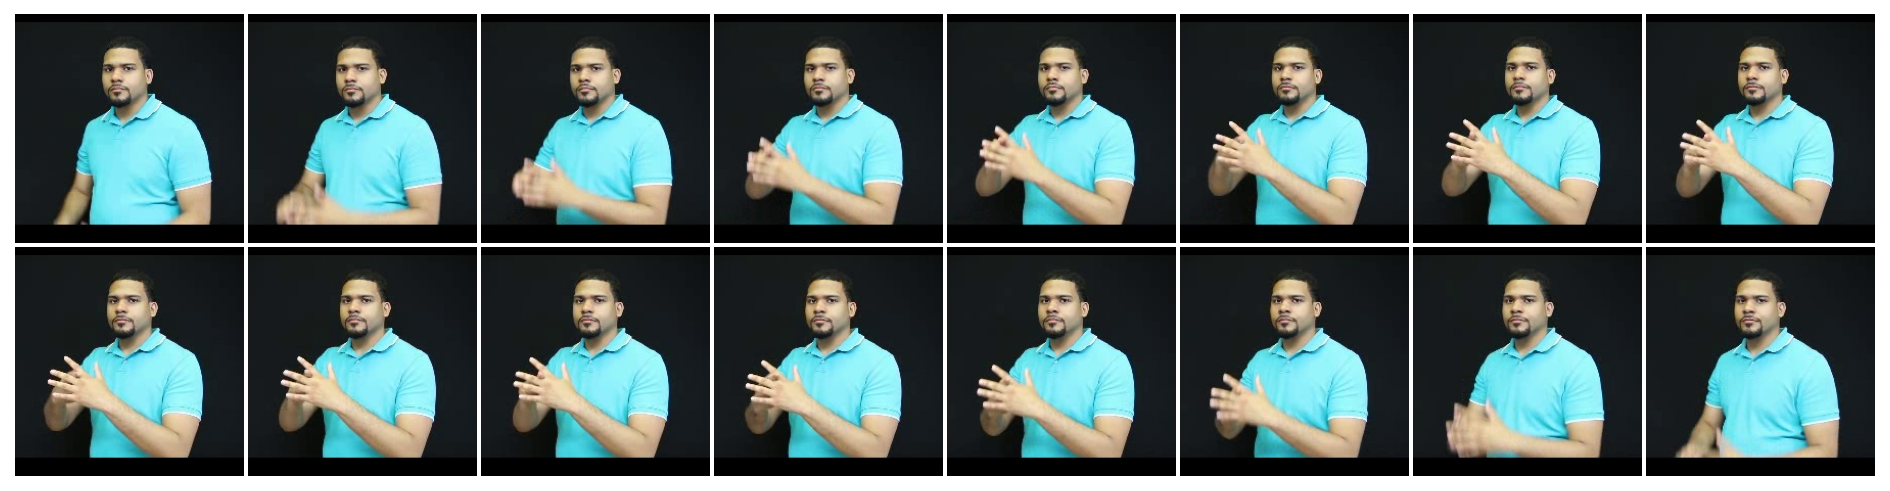

"come here" -- F1=1.00, 3 signers, 5 instances


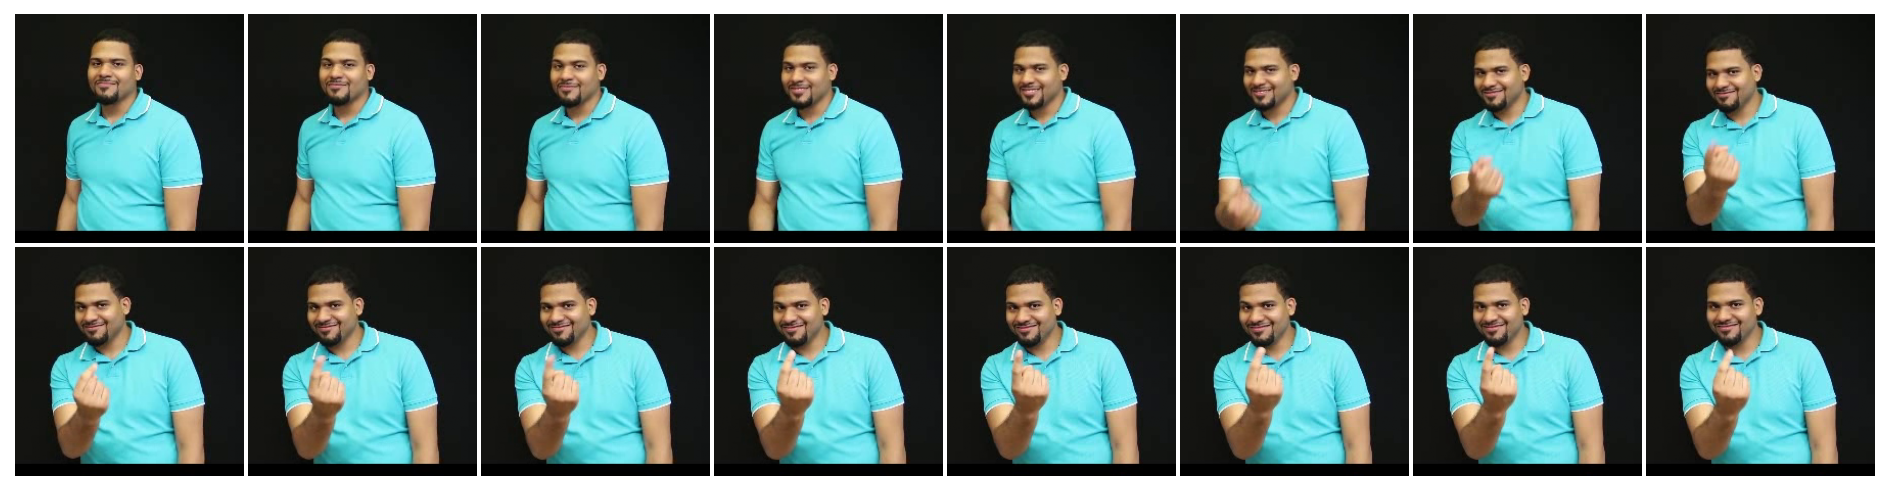

"swimsuit" -- F1=1.00, 3 signers, 5 instances


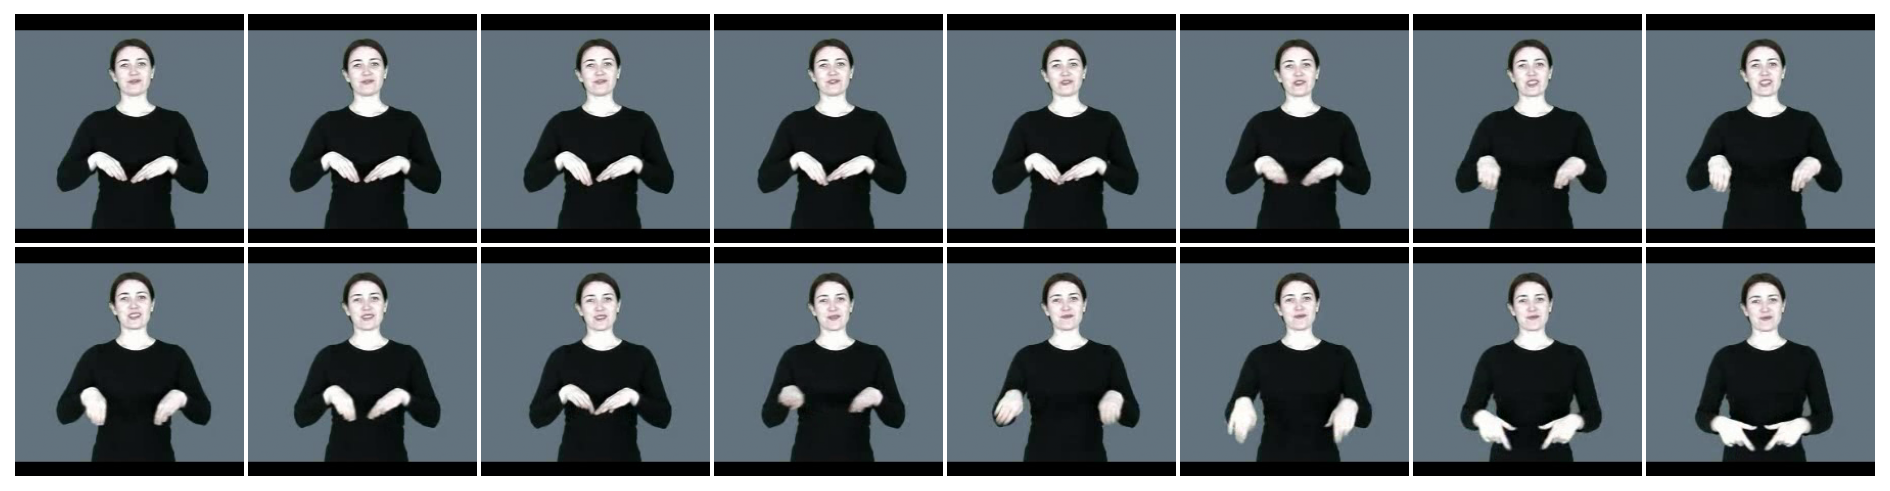

"wash face" -- F1=1.00, 3 signers, 5 instances


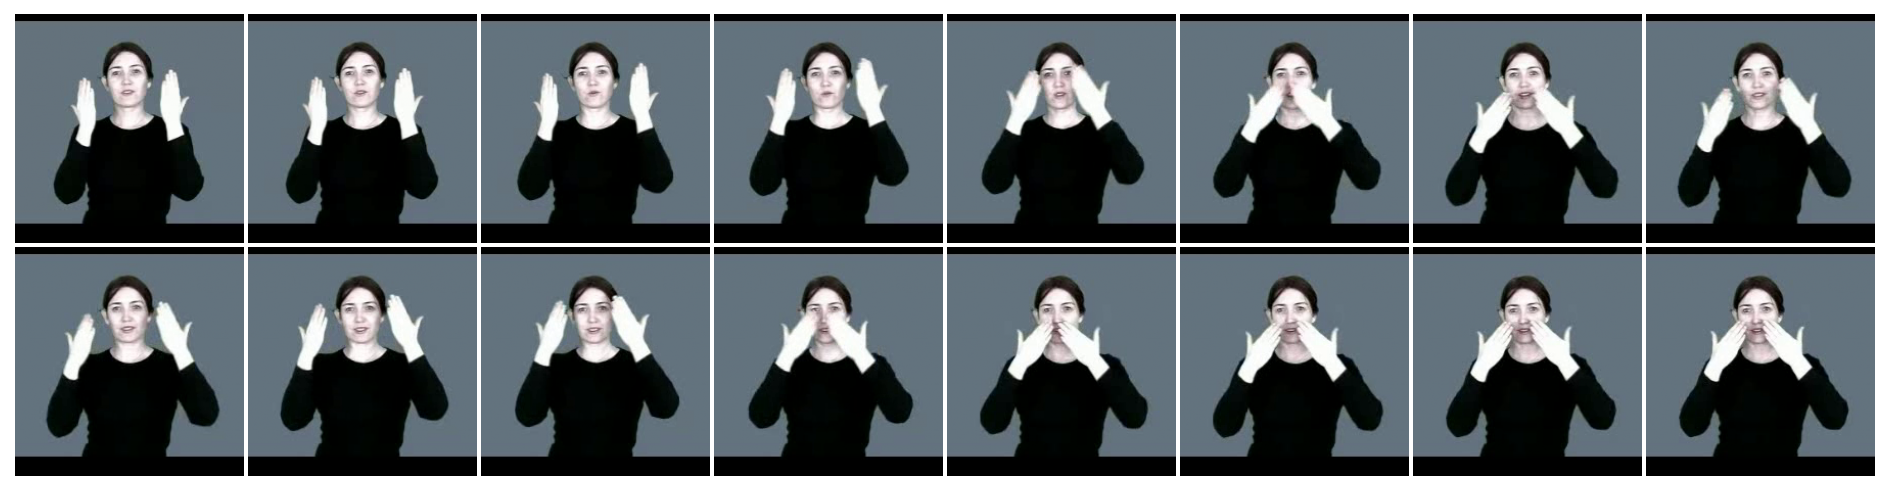

In [5]:
for _, row in overachievers_df.iterrows():
    gloss = row['Gloss']
    print(f'"{gloss}" -- F1={row["F1_Score"]:.2f}, {row["Signers"]} signers, {row["Instances"]} instances')
    frames = FrameFetcher(
        cls_idx=class_to_idx[gloss],
        all_sets=all_sets,
        set_name=set_name,
        split_name=split_name,
        target_length=target_length,
    )()
    plt_display_grid(frames, num=target_length, size=grid_cell_size)

## Underachieving glosses

High signer count, but the model still gets these wrong -- and what it
predicts instead (the most common misprediction across the test set).

"before" -- F1=0.00, 13 signers, 18 instances


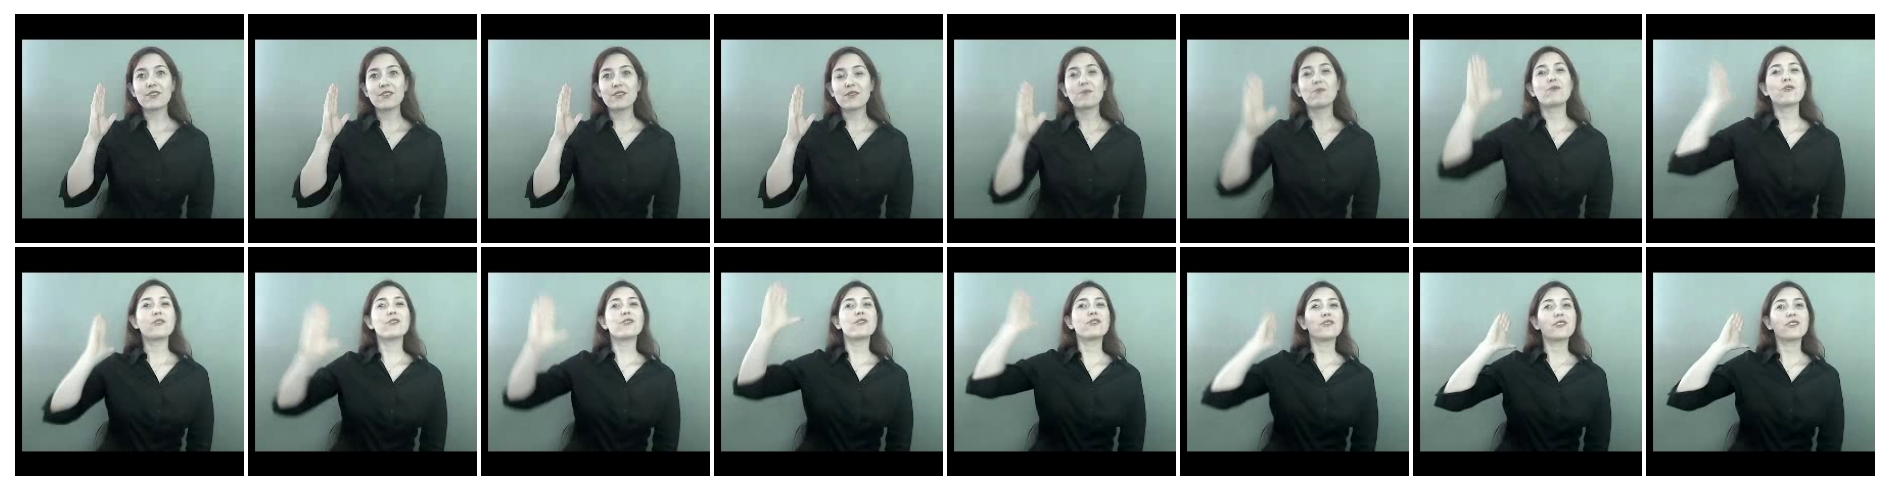

Most common misprediction: "former" (1/4 wrong instances)


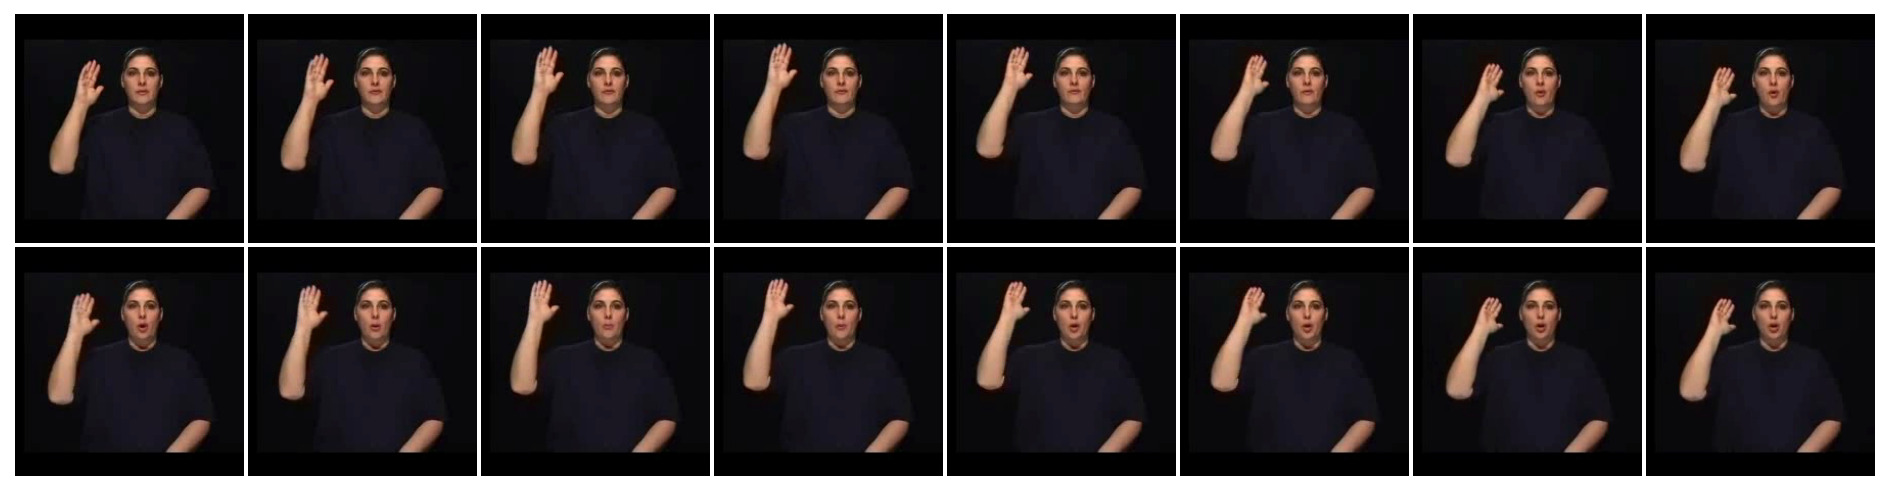

"thin" -- F1=0.00, 13 signers, 15 instances


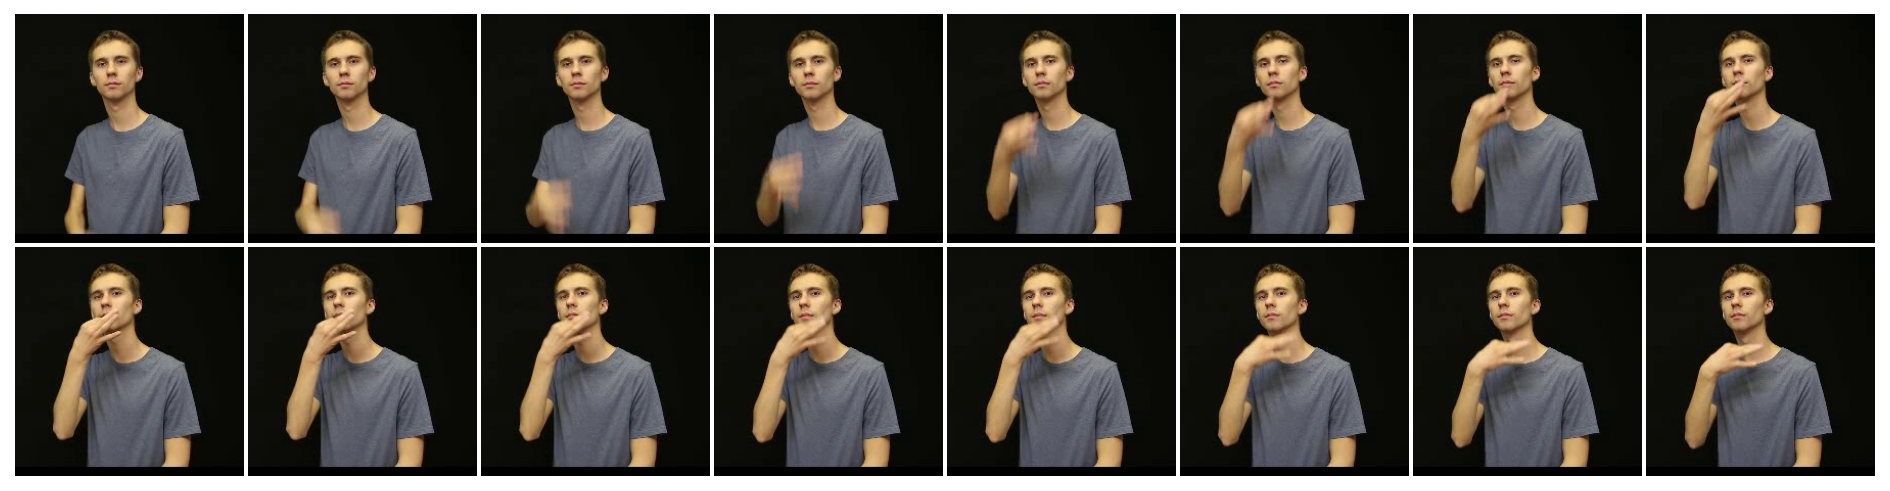

Most common misprediction: "expert" (1/3 wrong instances)


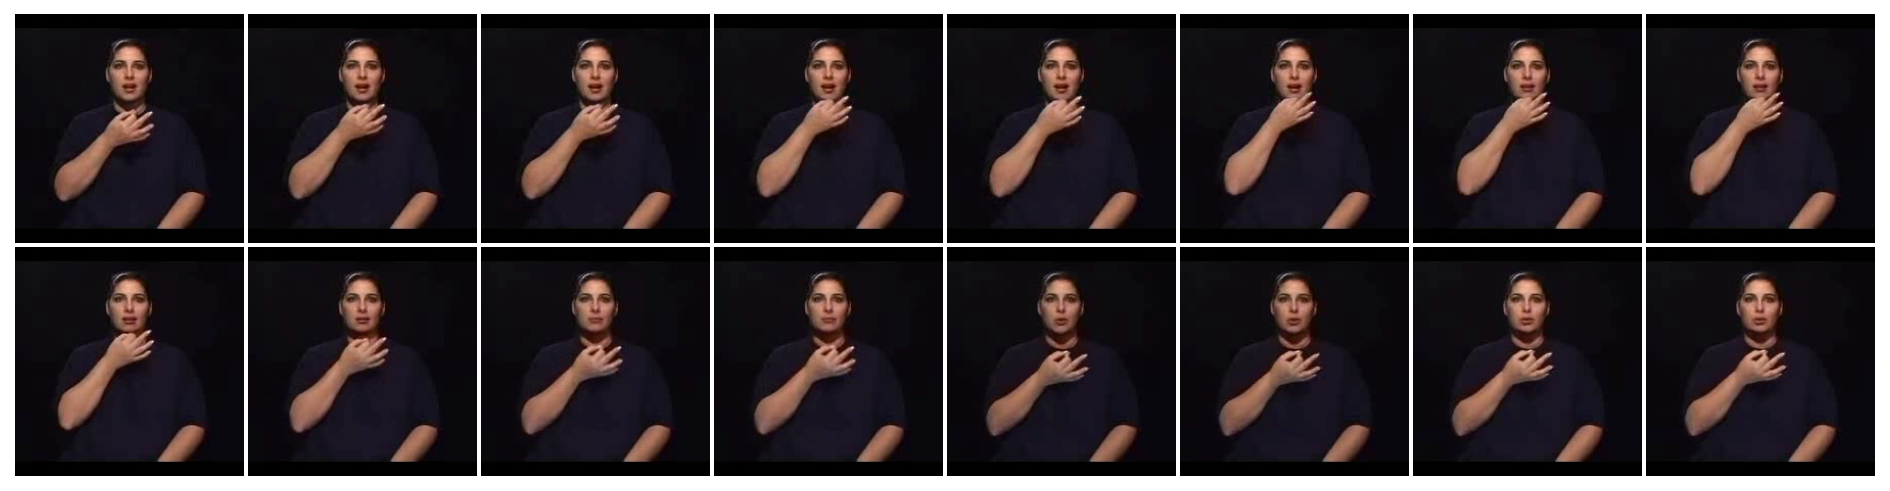

"eat" -- F1=0.00, 13 signers, 14 instances


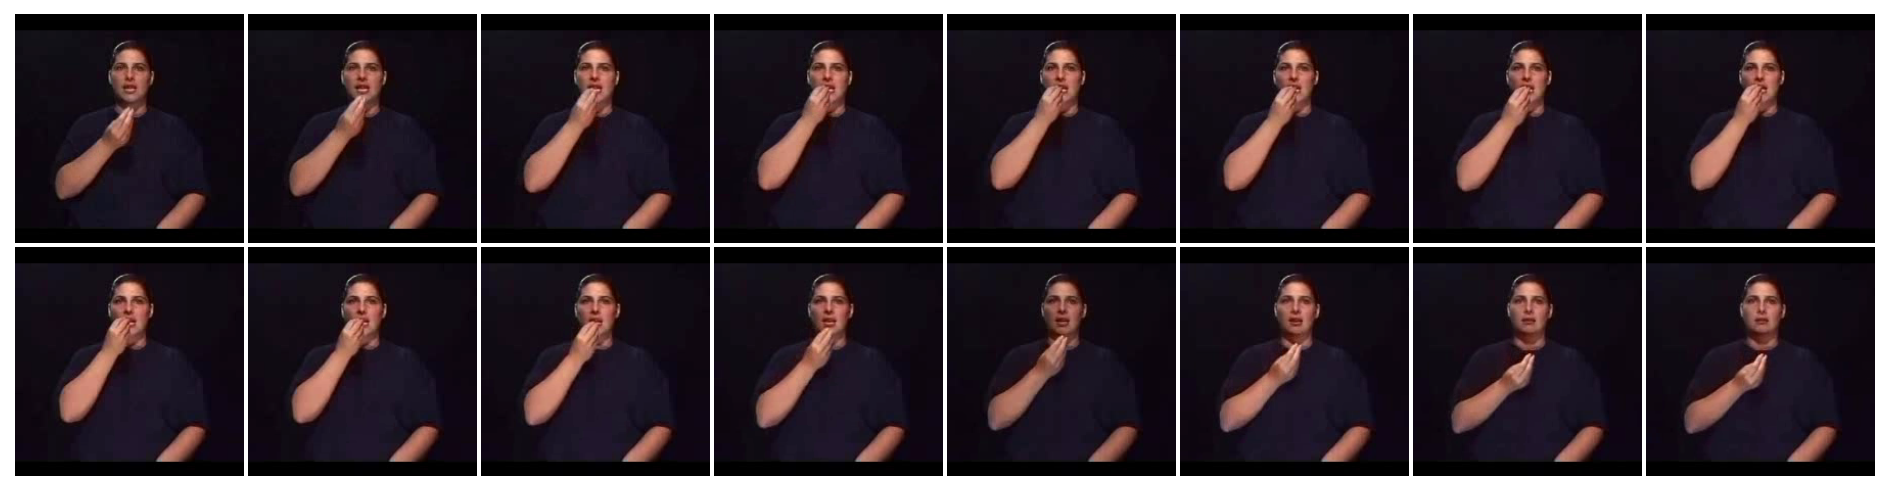

Most common misprediction: "good" (1/2 wrong instances)


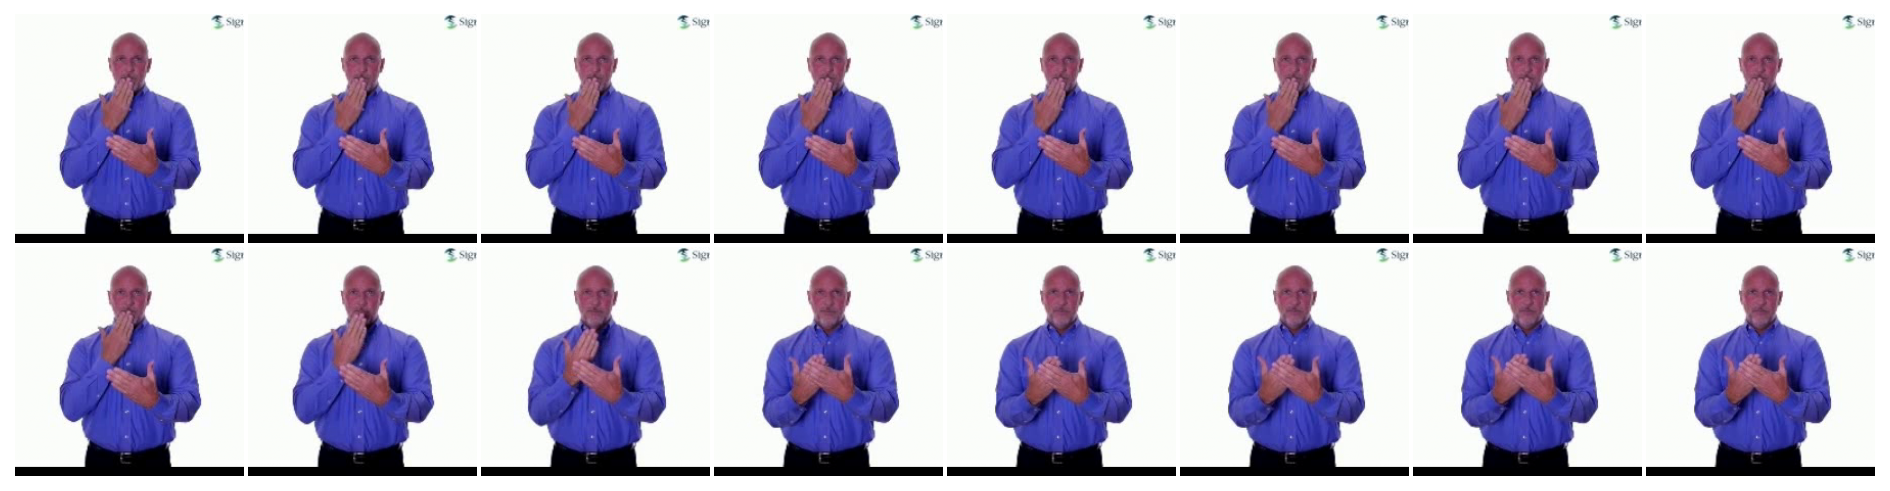

"yellow" -- F1=0.00, 13 signers, 13 instances


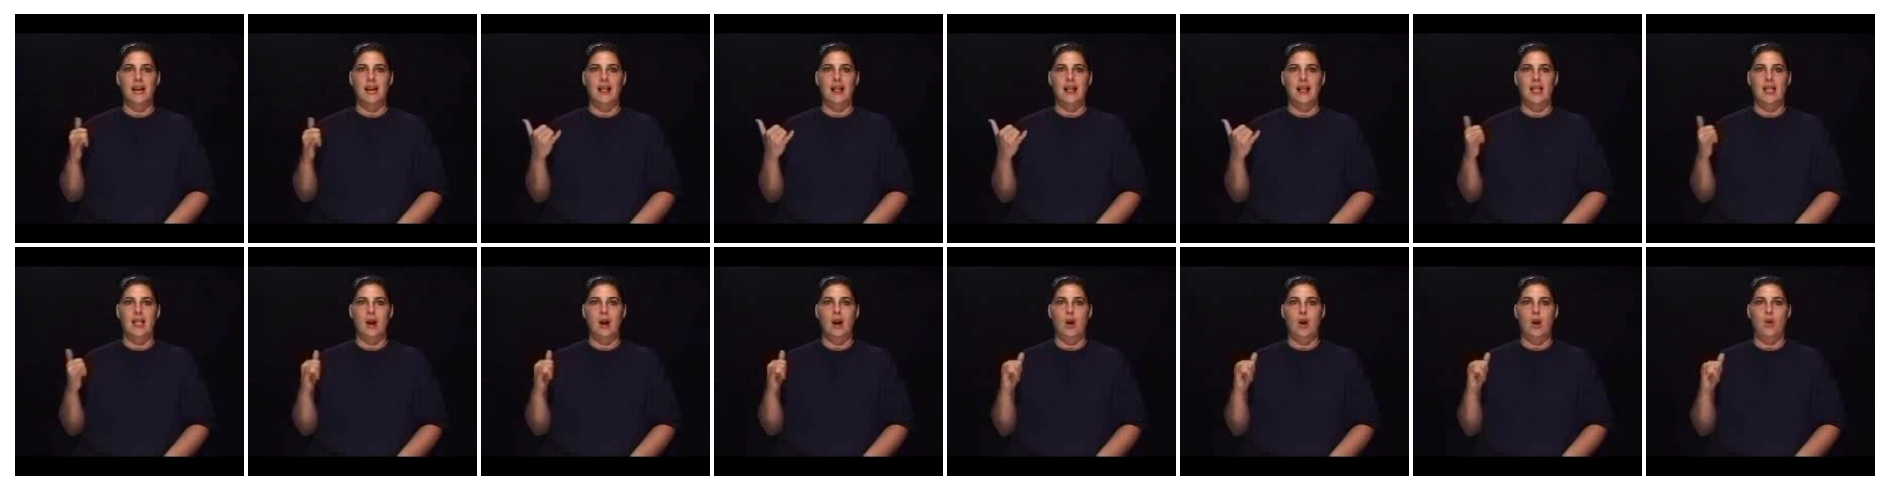

Most common misprediction: "only" (1/2 wrong instances)


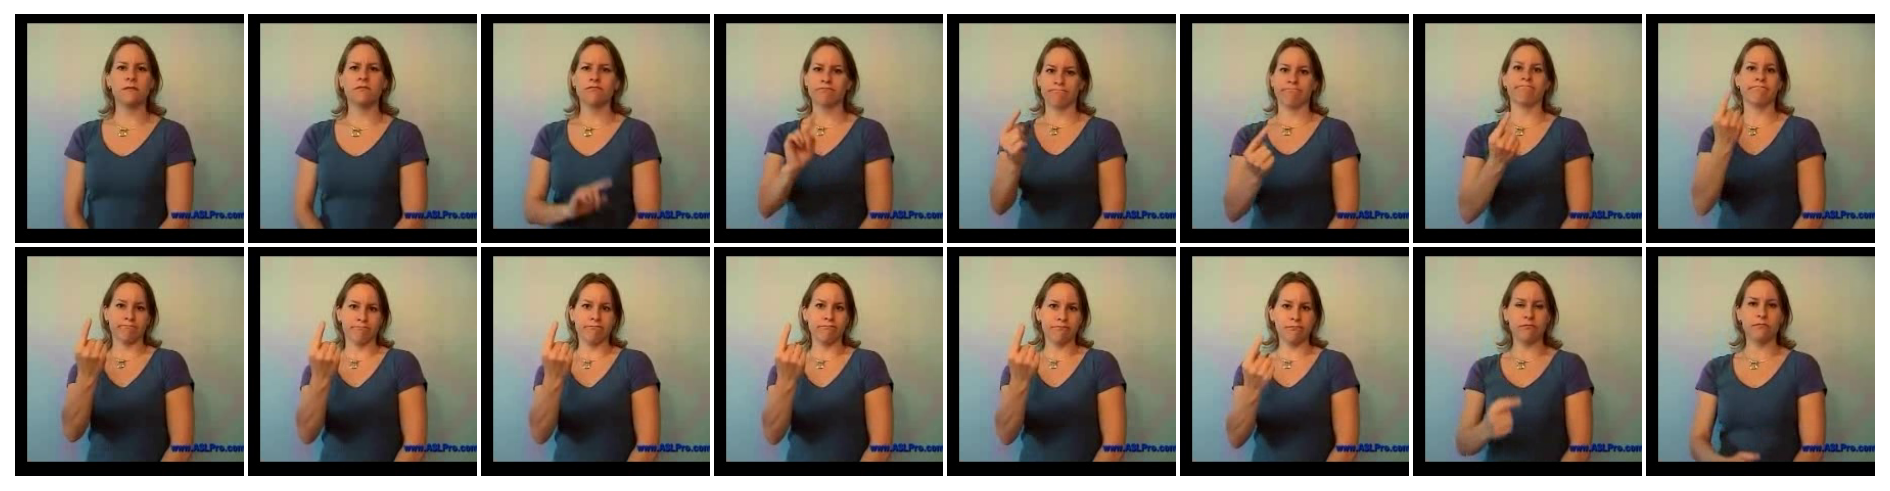

"what" -- F1=0.00, 12 signers, 14 instances


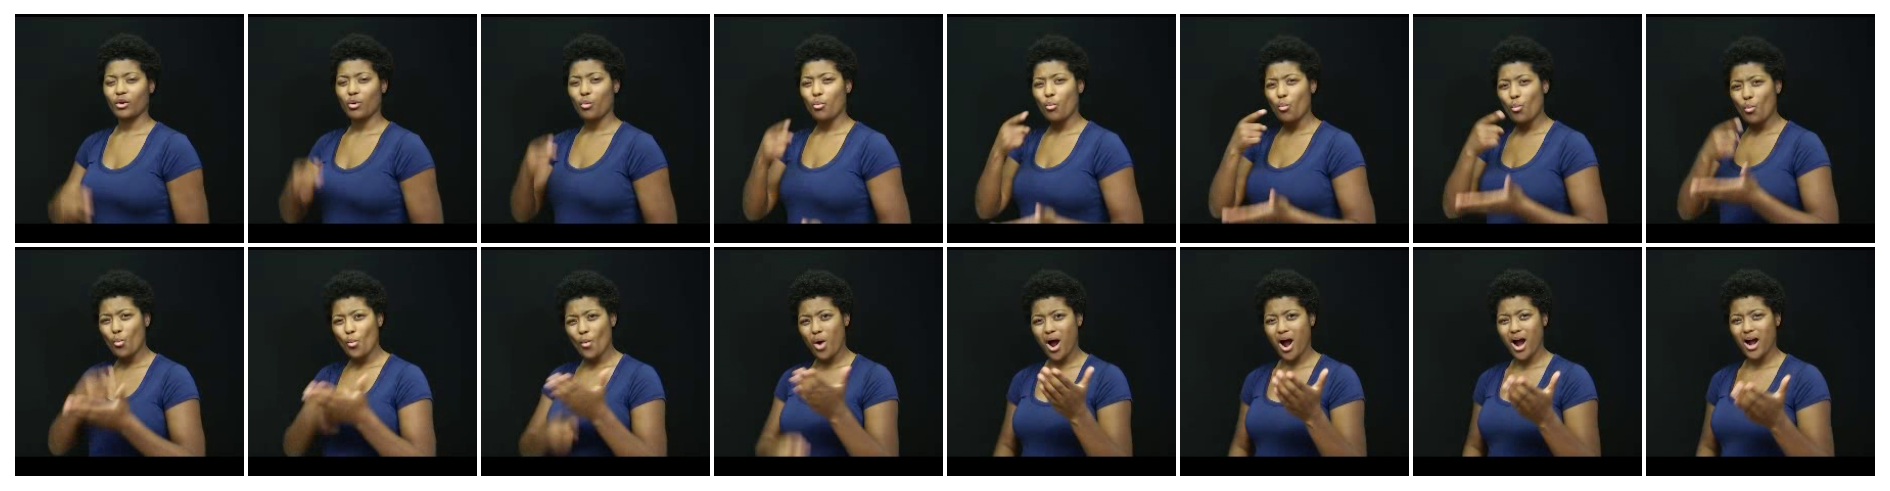

Most common misprediction: "cost" (1/3 wrong instances)


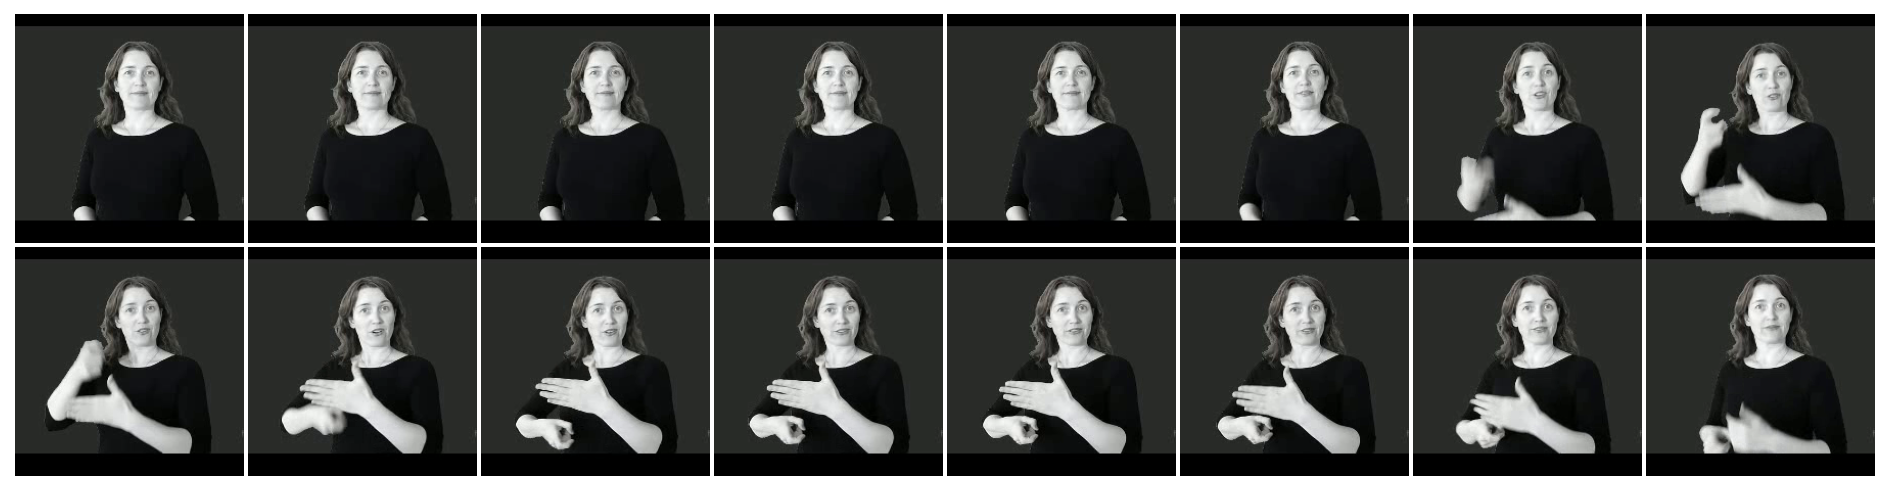

In [6]:
for _, row in underachievers_df.head(num_underachievers_shown).iterrows():
    gloss = row['Gloss']
    cls_idx = class_to_idx[gloss]
    print(f'"{gloss}" -- F1={row["F1_Score"]:.2f}, {row["Signers"]} signers, {row["Instances"]} instances')
    frames = FrameFetcher(
        cls_idx=cls_idx,
        all_sets=all_sets,
        set_name=set_name,
        split_name=split_name,
        target_length=target_length,
    )()
    plt_display_grid(frames, num=target_length, size=grid_cell_size)

    wrong_preds = [p for t, p in zip(all_targets, all_preds) if t == cls_idx and p != cls_idx]
    if not wrong_preds:
        print('No misclassified instances found for this gloss.')
        continue

    predicted_idx, count = Counter(wrong_preds).most_common(1)[0]
    predicted_gloss = classes[predicted_idx]
    print(f'Most common misprediction: "{predicted_gloss}" ({count}/{len(wrong_preds)} wrong instances)')
    pred_frames = FrameFetcher(
        cls_idx=predicted_idx,
        all_sets=all_sets,
        set_name=set_name,
        split_name=split_name,
        target_length=target_length,
    )()
    plt_display_grid(pred_frames, num=target_length, size=grid_cell_size)